In [2]:
import pandas as pd

df = pd.read_csv("../data/cleaned_dataset_for_EDA.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


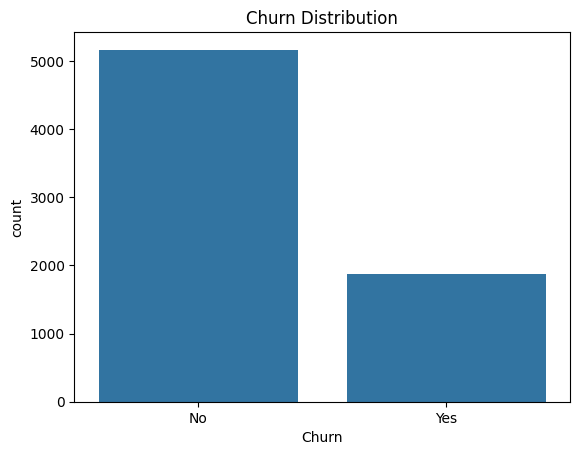

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

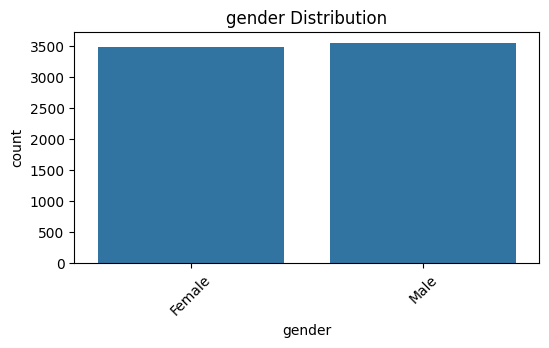

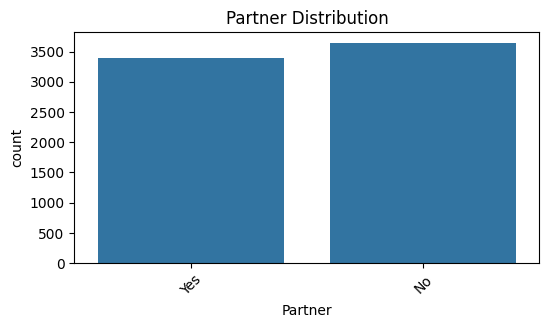

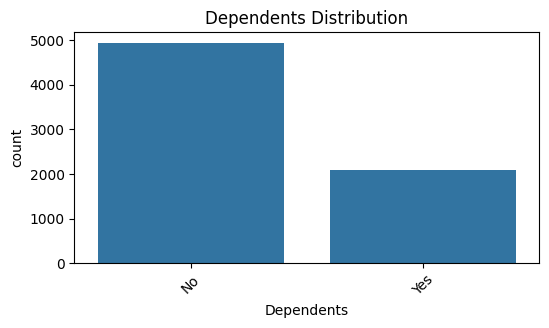

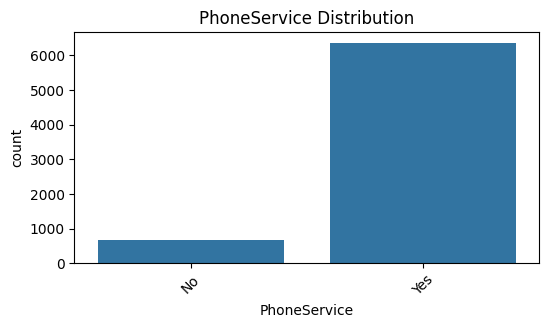

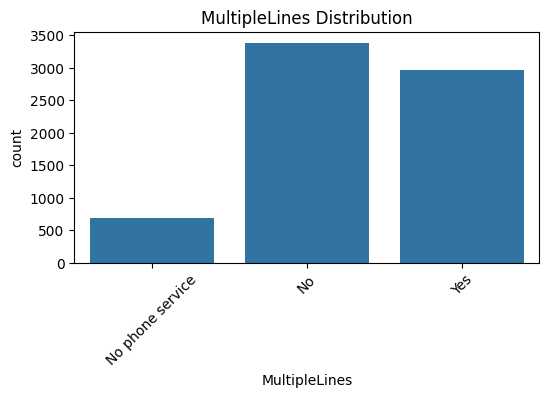

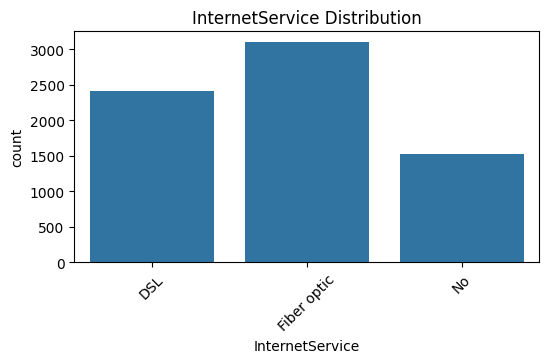

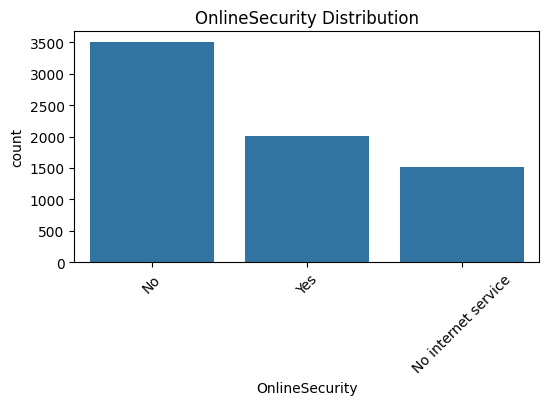

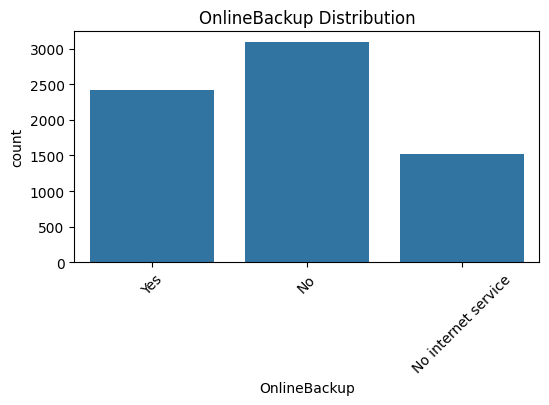

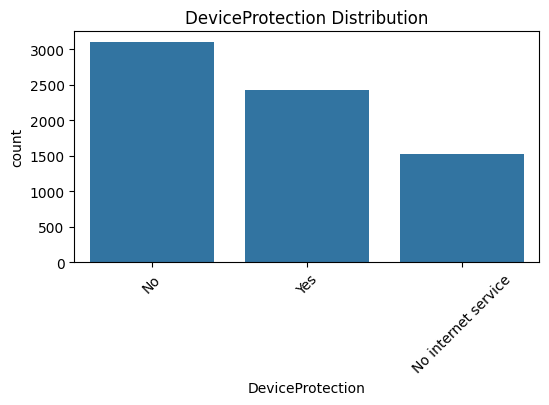

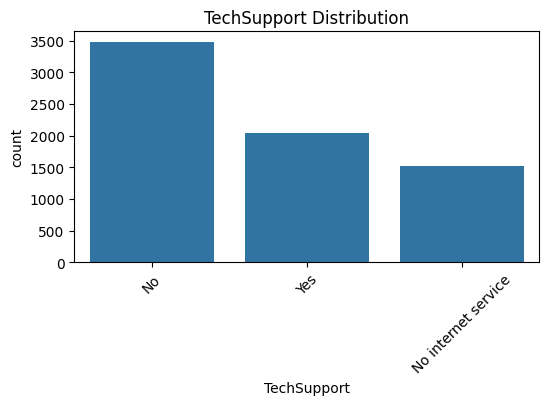

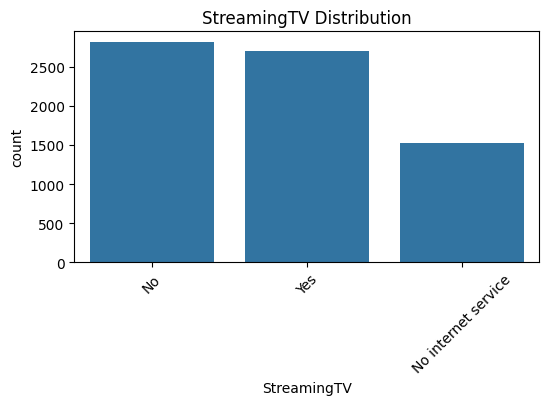

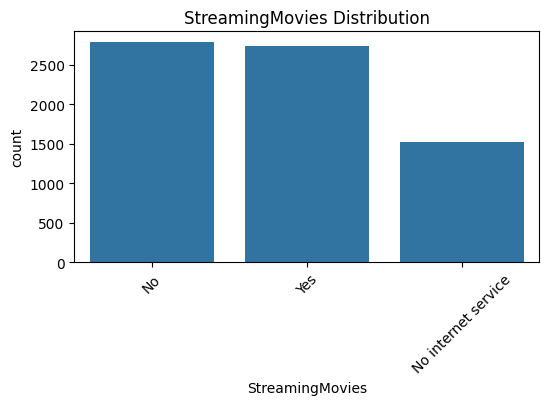

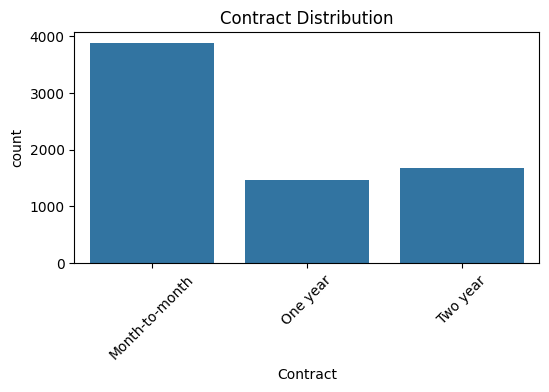

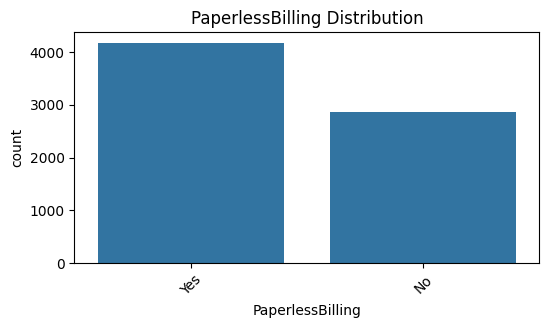

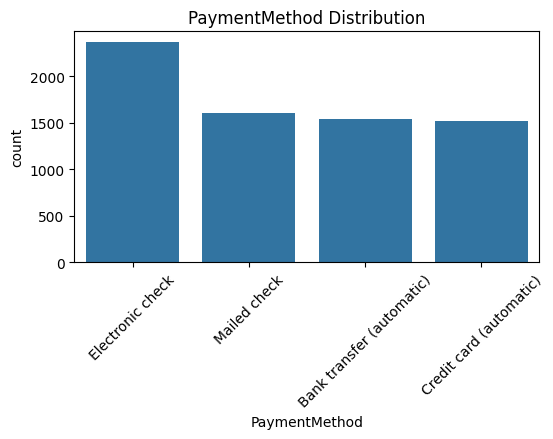

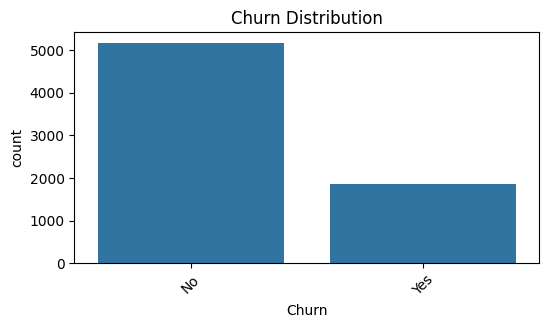

In [5]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols = [col for col in categorical_cols if col != "customerID"]

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

# Target and Feature Distribution Analysis (Graphs interpretation)

## 1. Churn Distribution Report

The Churn plot reveals a significant imbalance in our target variable:

* **No (Stayed):** ~5,174 customers (**~73.5%**)
* **Yes (Left):** ~1,858 customers (**~26.5%**)

**Analytical Note:** Since approximately one-quarter of our customers churned, we are dealing with an **imbalanced dataset**. If a model simply predicted "No" for every customer, it would achieve 73.5% accuracy while failing to identify any churn risk. In the next phases, we must prioritize **Recall** (identifying potential leavers) and **Precision** over simple accuracy.

---

## 2. Categorical Distribution and Simplification Opportunities

Based on the distribution of features, we can identify categories that are either dominant or candidates for simplification during the feature engineering stage:

### A. High-Dominance Categories (Limited Variance)

* **PhoneService:** A vast majority of customers have phone service. The "No" group is a small niche, suggesting this may have low predictive power compared to internet-related features.
* **MultipleLines:** The "No phone service" group is a logical subset of those without PhoneService. These could potentially be consolidated into a binary "Yes/No" if necessary.

### B. Grouping Candidates (Reducing Noise)

* **OnlineSecurity, OnlineBackup, TechSupport, etc.:** These features all contain a "No internet service" category.
* **Simplification Strategy:** These ~1,500 individuals are consistent across these columns. We can likely group "No internet service" with "No" for these specific features, as both values represent the absence of that service.

### C. Critical Drivers (High Variance)

* **Contract:** "Month-to-month" is the most frequent category. This is historically a high-volatility segment because there are no long-term switching costs.
* **PaymentMethod:** "Electronic check" is the most common method, but there is a healthy distribution across all four types, which is ideal for detecting correlations with churn.

---




### Summary
## 1. Churn Distribution Summary

* **Imbalance Confirmed:** 73% stayed, 27% left.
* **Analytical Takeaway:** Accuracy alone is a misleading metric for this project. We must prioritize **Recall** for churners to ensure the business actually identifies the customers at risk of leaving. This perspective distinguishes a business analyst from someone simply running a model.

---

## 2. Categorical Observations

* **Feature Categorization:** You have correctly identified binary versus multi-level features and determined which are dominant or rare.
* **Simplification Strategy:** Your note on "No internet service" is professional. Treating these as "No" reduces noise without losing information, though keeping them separate for a trial run is a valid way to check for unique behaviors.

---

## 3. High-Priority Features for Bivariate Analysis

Based on the initial inspection, the following variables are the most promising candidates for the next phase of analysis:

| Feature | Reason to Analyze Against Churn |
| --- | --- |
| **Contract** | Month-to-month contracts are likely to show significantly higher churn. |
| **InternetService** | Comparing Fiber optic vs. DSL may reveal service-specific dissatisfaction. |
| **PaymentMethod** | Electronic checks may correlate with higher churn compared to automated methods. |
| **OnlineSecurity / TechSupport** | Add-on adoption often affects "stickiness" and customer loyalty. |
| **Tenure** | Longer tenure generally correlates with lower churn risk. |
| **MonthlyCharges** | High charges are often a direct trigger for customers to shop for competitors. |

---


## Next Step — Bivariate Analysis 
Now that we understand each variable individually, we need to analyze how each feature relates to churn.

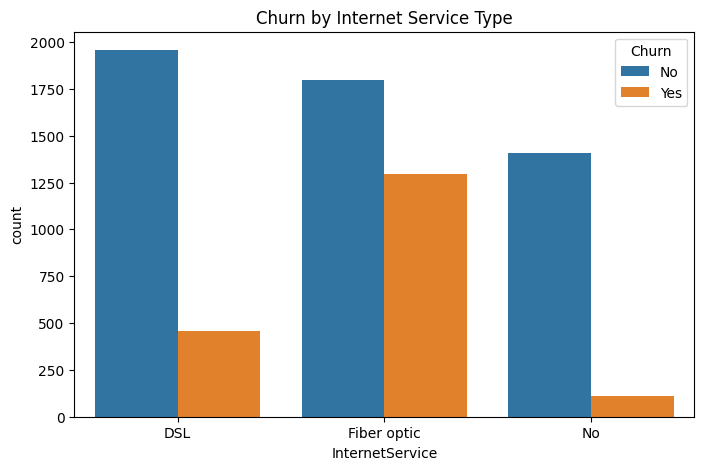

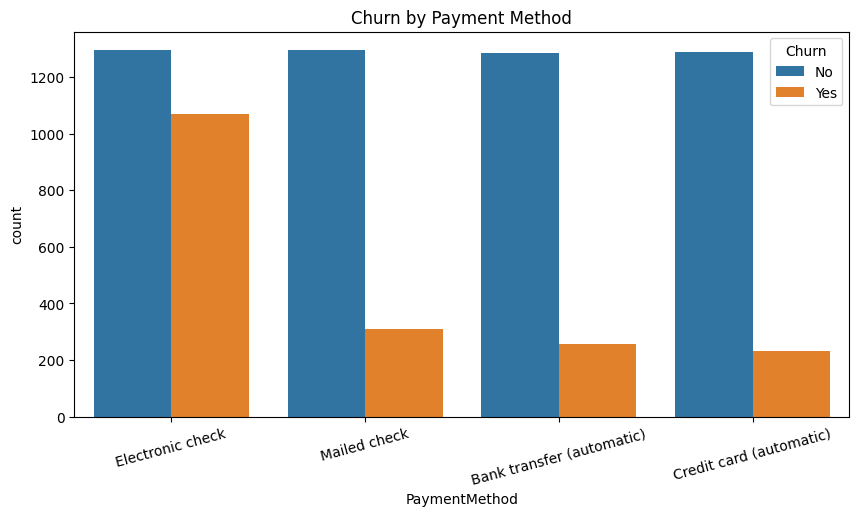

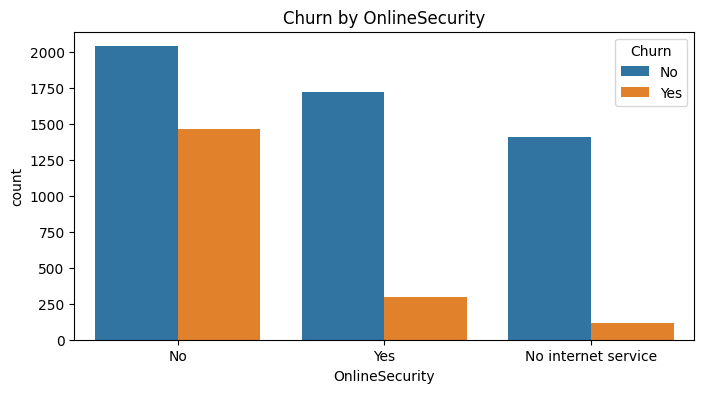

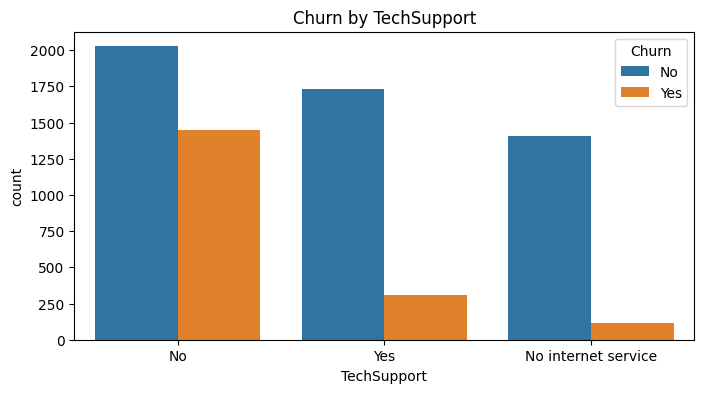

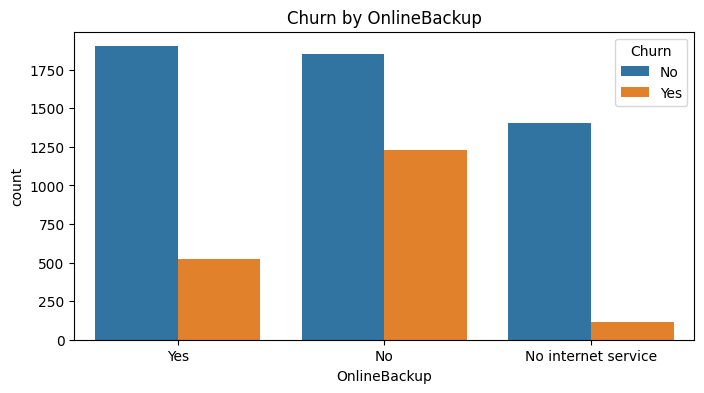

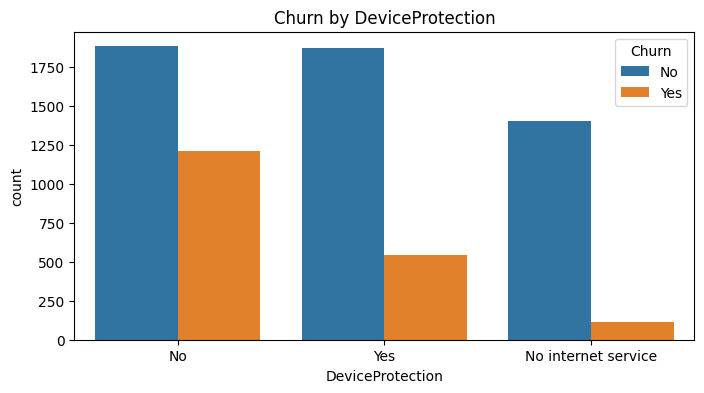

In [6]:
# 1. InternetService vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service Type")
plt.show()

# 2. PaymentMethod vs Churn
plt.figure(figsize=(10, 5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=15)
plt.show()

# 3. Add-ons (OnlineSecurity, TechSupport, etc.) vs Churn
# We can analyze several similar add-on columns at once
addons = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]

for addon in addons:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=addon, hue="Churn", data=df)
    plt.title(f"Churn by {addon}")
    plt.show()

## For numeric variables:

C:\Users\HP\AppData\Local\Temp\ipykernel_5520\4203795216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="tenure", data=df, palette="Set2")


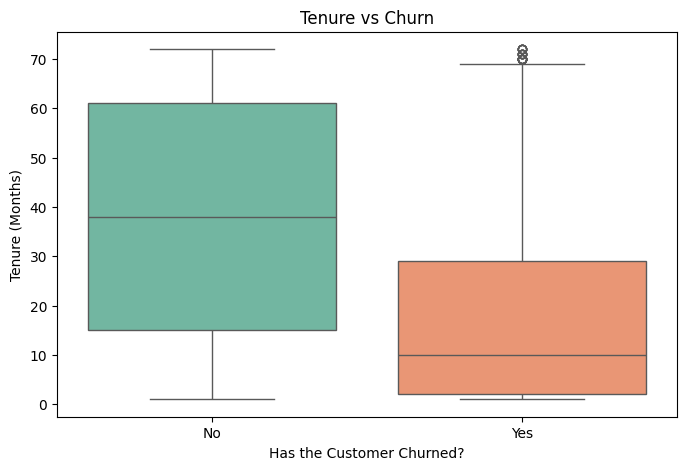

In [7]:
# 1. Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df, palette="Set2")
plt.title("Tenure vs Churn")
plt.xlabel("Has the Customer Churned?")
plt.ylabel("Tenure (Months)")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_5520\3044957014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set2")


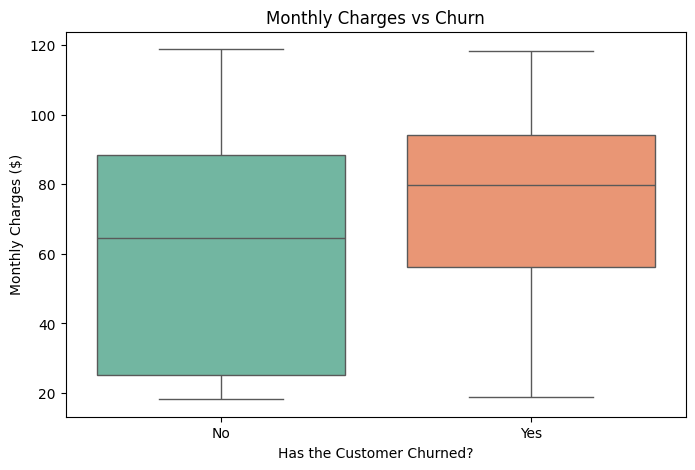

In [8]:
# 2. MonthlyCharges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set2")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Has the Customer Churned?")
plt.ylabel("Monthly Charges ($)")
plt.show()

## Bivariate Analysis Synthesis and Summary

## 1. Categorical Variables and Business Logic

The analysis of categorical features confirms that **Contract**, **InternetService**, **PaymentMethod**, and **Add-ons** are strongly predictive of churn.

* **Strategic Insight:** We have identified the business logic behind the patterns. For example, the high churn in Month-to-month contracts reflects a lack of financial or contractual switching costs. Fiber optic churn suggests that speed alone does not guarantee loyalty if price or service reliability is an issue.
* **Feature Engineering Note:** These insights guide our encoding strategy. We now know which features require careful preservation of their categories to maintain their predictive power.

---

## 2. Numerical Variable Trends

The interaction between **Tenure** and **MonthlyCharges** provides a clear quantitative signal for our future model:

* **Trend identified:** Low tenure combined with high monthly charges creates a high-risk zone.
* **Model Utility:** This helps the machine learning model detect specific numeric thresholds. For instance, customers in their first 12 months paying above $70/month may require automatic flagging for retention interventions.

---

## 3. High-Risk Customer Profile

By synthesizing the categorical and numerical findings, we have defined the typical profile of a customer likely to churn.

* **Profile Characteristics:** A customer on a Month-to-month plan, using Fiber Optic internet, paying via Electronic Check, with less than one year of tenure and a high monthly bill.
* **Business Value:** This is the exact type of qualitative insight that management requires to understand the "why" before looking at "what" the machine learning model predicts. We are no longer just looking at numbers; we are looking at specific customer behaviors.

---


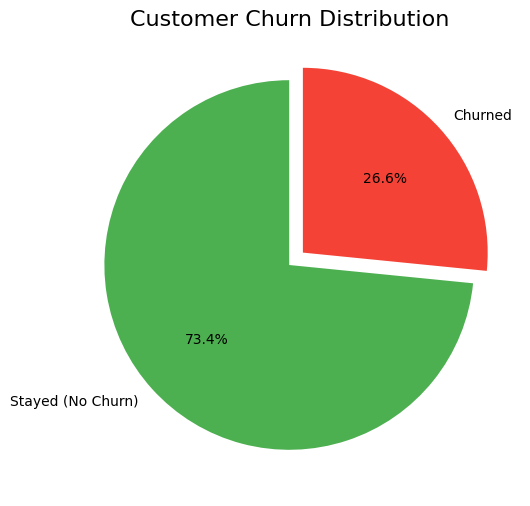

In [9]:
#Churn Distribution Pie Chart
import matplotlib.pyplot as plt

# Count churn vs non-churn
churn_counts = df['Churn'].value_counts()
labels = ['Stayed (No Churn)', 'Churned']
colors = ['#4CAF50', '#F44336']

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.1))
plt.title('Customer Churn Distribution', fontsize=16)
plt.show()

Explanation:

* Green = customers who stayed

* Red = churned customers (~27%)

* Explode on the churn slice emphasizes the at-risk segment

C:\Users\HP\AppData\Local\Temp\ipykernel_5520\92573500.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette=['#66b3ff','#ff6666'])


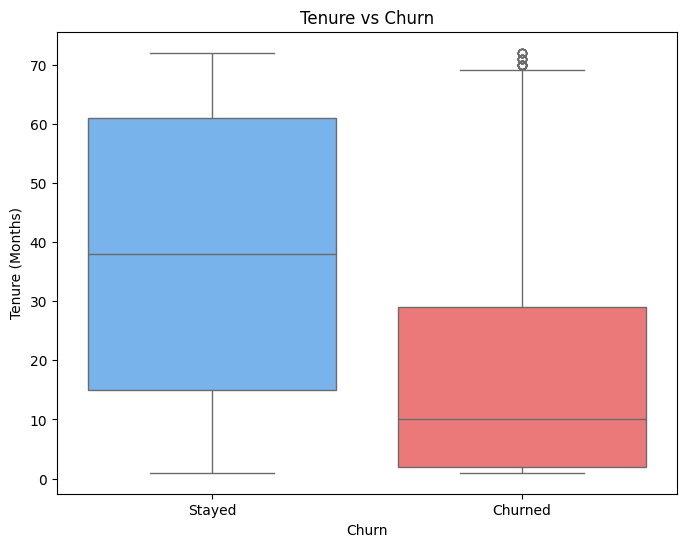

In [10]:
#Tenure vs Churn Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='tenure', data=df, palette=['#66b3ff','#ff6666'])
plt.xticks([0,1], ['Stayed','Churned'])
plt.ylabel('Tenure (Months)')
plt.title('Tenure vs Churn')
plt.show()

Explanation:

* Shows early churn risk: churned customers typically have low tenure.

* Visualizes the “burn-in” period: if a customer stays past ~12 months, likelihood of leaving drops.

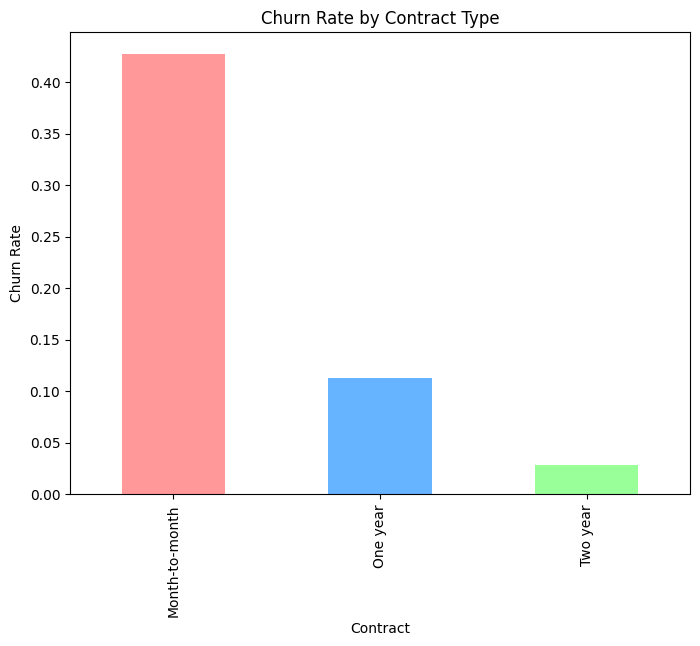

In [11]:
# Contract Type vs Churn Rate
# Ensure 'Churn' is numeric (0 for No, 1 for Yes) for mean calculation
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

contract_churn = df.groupby('Contract')['Churn'].mean()

plt.figure(figsize=(8,6))
contract_churn.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'])
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.show()

Explanation:

* Month-to-month contracts show highest churn rate.

* One-year and two-year contracts are much more stable, confirming the “locking effect.”

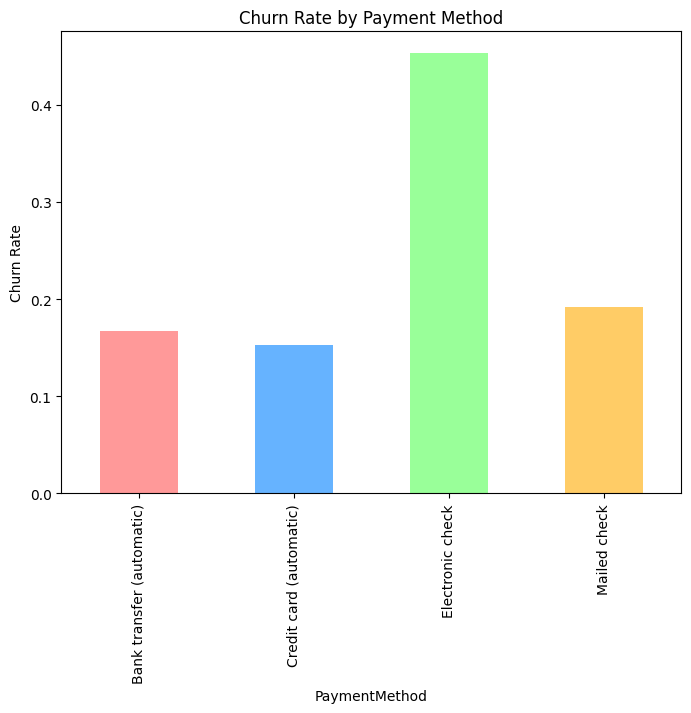

In [12]:
#Payment Method vs Churn Rate
payment_churn = df.groupby('PaymentMethod')['Churn'].mean()

plt.figure(figsize=(8,6))
payment_churn.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99','#ffcc66'])
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Payment Method')
plt.show()

Explanation:

* Customers using manual payments (Electronic Check) churn the most.

* Automated payments (Credit Card, Bank Transfer) reduce churn due to continuity and frictionless service.

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')